# 05 – Model Evaluation and Error Analysis

In this notebook, we evaluate the baseline genre classification model in more detail.

Instead of only reporting accuracy, we analyze which genres are classified correctly and where the model makes mistakes.

## Goals

By the end of this notebook, we can:

- train the baseline classifier on multiple genres
- evaluate the model using accuracy and a classification report
- visualize errors with a confusion matrix
- identify which genres are commonly confused
- inspect feature importance of the Random Forest model

## 1. Imports

We use `librosa` for audio feature extraction, `scikit-learn` for model training and evaluation, and `matplotlib` for visualization.

In [2]:
import numpy as np
import librosa
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## 2. Dataset Setup

We extend the classification task to four music genres.

Using more genres makes the task more realistic and allows us to analyze which genres are easier or harder to separate.

In [3]:
genres = ["rock", "classical", "jazz", "metal"]

## 3. MFCC Feature Extraction

As in the baseline notebook, we use MFCCs as compact audio features.

For each audio file, MFCCs are computed and then averaged over time, resulting in one fixed-size feature vector per song.

In [4]:
def extract_mfcc(file_path, n_mfcc=13):

    y, sr = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )

    mfcc_mean = np.mean(mfcc, axis=1)

    return mfcc_mean

Averaging MFCCs over time makes the feature representation simple and suitable for classical machine learning models.

However, this also removes temporal information, which may be important for distinguishing some music genres.

In [5]:
data_path = Path("../data/raw/gtzan/Data/genres_original")

In [6]:
X = []
y = []

for genre in genres:

    genre_path = data_path / genre

    files = list(genre_path.glob("*.wav"))[:30]

    for file in files:

        features = extract_mfcc(file)

        X.append(features)
        y.append(genre)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (120, 13)


The dataset contains 120 samples in total.

Each sample is represented by 13 MFCC features, which summarize the spectral characteristics of an audio file.

## 4. Train/Test Split

The dataset is split into training and test data.

The model learns from the training set and is evaluated only on the test set to estimate how well it performs on unseen examples.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5. Train Random Forest Classifier

We use a Random Forest classifier as a baseline model.

Random Forests are useful for tabular feature vectors such as averaged MFCCs and provide feature importance values for interpretation.

In [8]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

The model has now learned patterns in the MFCC feature vectors that may help distinguish between genres.

In [9]:
y_pred = model.predict(X_test)

## 6. Classification Report

Accuracy gives a first overview of model performance, but it does not show how well each individual genre is classified.

Therefore, we also inspect precision, recall, and F1-score for each class.

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7916666666666666


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   classical       0.83      0.83      0.83         6
        jazz       0.62      0.83      0.71         6
       metal       1.00      0.83      0.91         6
        rock       0.80      0.67      0.73         6

    accuracy                           0.79        24
   macro avg       0.81      0.79      0.80        24
weighted avg       0.81      0.79      0.80        24



The model achieves about 79% accuracy on the test set.

The class-wise scores show that some genres are classified more reliably than others.

## 7. Confusion Matrix

A confusion matrix shows where the model makes mistakes.

Rows represent the true labels, while columns represent the predicted labels.  
Values on the diagonal are correct predictions, and off-diagonal values are classification errors.

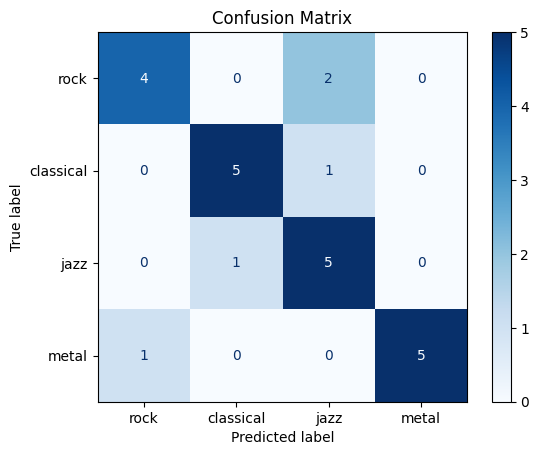

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=genres)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=genres
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that most samples are classified correctly.

The main errors occur between genres with similar acoustic characteristics, especially rock and metal.

## 8. Feature Importance

Random Forest models can estimate how important each feature was for the classification.

Here, we visualize the importance of the 13 MFCC features.

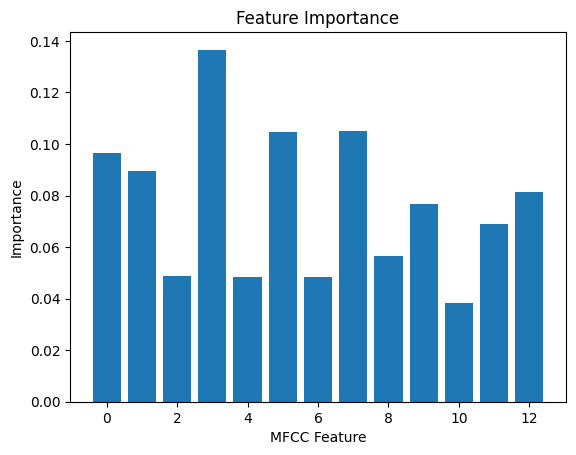

In [13]:
importances = model.feature_importances_

plt.bar(range(len(importances)), importances)
plt.xlabel("MFCC Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

Some MFCC features contribute more strongly to the model decision than others.

This suggests that not all MFCC coefficients are equally useful for distinguishing music genres.

## Observations

- The model performs reasonably well on the four selected genres.
- Classical and metal are classified more accurately than some other genres.
- Rock and metal show some confusion, likely because they share similar spectral and rhythmic characteristics.
- The confusion matrix provides more detailed insight than accuracy alone.
- Feature importance indicates that some MFCC coefficients are more relevant for classification than others.
- MFCC features provide a useful baseline, but they may not capture all musical characteristics.

## Week 5 Summary

In this week, we evaluated the baseline genre classification model in more detail:

- Extended the classification task to four genres
- Extracted averaged MFCC features from audio files
- Trained a Random Forest classifier
- Evaluated the model using accuracy and a classification report
- Visualized classification errors with a confusion matrix
- Inspected feature importance values of the model

The results show that the baseline model can distinguish several genres reasonably well, but some genre pairs are still confused.  
This indicates that stronger feature representations or more advanced models may be needed for better generalization.

## Next Steps

Future improvements could include:

- using more audio samples and all available genres
- applying cross-validation for more reliable evaluation
- comparing different classifiers
- adding more audio features
- using full Mel-spectrograms with CNN-based models